In [1]:
!pip install pillow pandas faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 81.6 MB/s  0:00:00

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [30]:
from PIL import Image, ImageDraw, ImageFont
from faker import Faker
import pandas as pd
import random
import string
import os

fake = Faker('en_IN')

os.makedirs("pan_images", exist_ok=True)


In [31]:
def generate_pan():
    letters = ''.join(random.choices(string.ascii_uppercase, k=5))
    digits = ''.join(random.choices(string.digits, k=4))
    last_letter = random.choice(string.ascii_uppercase)

    return letters + digits + last_letter

In [33]:
import os

os.makedirs(
    "data",
    exist_ok=True
)

os.makedirs(
    "data/pan_images",
    exist_ok=True
)

In [36]:
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont

import random
import os
import pandas as pd


# ==========================
# CREATE FOLDERS
# ==========================

os.makedirs(
    "data",
    exist_ok=True
)

os.makedirs(
    "data/pan_images",
    exist_ok=True
)


# ==========================
# RANDOM DATA
# ==========================

first_names = [

    "Aarav","Vihaan","Aditya","Kabir","Laksh",
    "Arjun","Rohan","Ayaan","Hritik","Aryan",

    "Aanya","Diya","Ananya","Riya","Kiara",
    "Ishita","Sara","Myra","Kavya","Avni",

    "Rahul","Amit","Sneha","Pooja","Ritika",
    "Sakshi","Neha","Dev","Manav","Karan",

    "Priya","Tanvi","Ankit","Ritesh","Akash",
    "Raghav","Nikhil","Ritu","Maya","Tanya"

]


surnames = [

    "Mehta","Sharma","Yadav","Saxena","Kaul",
    "Gupta","Agarwal","Patel","Kapoor","Singh",

    "Verma","Bansal","Chopra","Reddy","Nair",
    "Mishra","Joshi","Kumar","Jain","Malhotra",

    "Sinha","Tripathi","Deshmukh","Kulkarni",
    "Chauhan","Soni","Bhatt","Pandey","Rao",
    "Iyer"

]


# ==========================
# HELPERS
# ==========================

def generate_name():

    return (

        random.choice(
            first_names
        )

        +

        " "

        +

        random.choice(
            surnames
        )

    )


def generate_pan():

    chars = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

    return (

        "".join(
            random.choices(
                chars,
                k=5
            )
        )

        +

        str(
            random.randint(
                1000,
                9999
            )
        )

        +

        random.choice(
            chars
        )

    )


def generate_dob():

    return (

        f"{random.randint(1,28):02}/"

        +

        f"{random.randint(1,12):02}/"

        +

        str(
            random.randint(
                1970,
                2005
            )
        )

    )


# ==========================
# CREATE IMAGE
# ==========================

def create_pan_card(

    name,
    dob,
    pan,
    output_path

):

    img = Image.new(
        "RGB",
        (1000, 600),
        (240, 245, 255)
    )

    draw = ImageDraw.Draw(
        img
    )

    try:

        title_font = ImageFont.truetype(
            "DejaVuSans-Bold.ttf",
            34
        )

        text_font = ImageFont.truetype(
            "DejaVuSans.ttf",
            28
        )

    except:

        title_font = None
        text_font = None


    draw.text(
        (40,40),
        "INCOME TAX DEPARTMENT",
        fill="black",
        font=title_font
    )

    draw.text(
        (40,90),
        "GOVERNMENT OF INDIA",
        fill="black",
        font=title_font
    )

    draw.text(
        (40,220),
        f"Name: {name}",
        fill="black",
        font=text_font
    )

    draw.text(
        (40,300),
        f"DOB: {dob}",
        fill="black",
        font=text_font
    )

    draw.text(
        (40,400),
        f"PAN: {pan}",
        fill="blue",
        font=title_font
    )

    os.makedirs(
        os.path.dirname(
            output_path
        ),
        exist_ok=True
    )

    img.save(
        output_path
    )


# ==========================
# GENERATE 100 RECORDS
# ==========================

records = []

for i in range(1,101):

    name = generate_name()

    dob = generate_dob()

    pan = generate_pan()

    income = random.randint(
        300000,
        3000000
    )

    image_path = (
        f"data/pan_images/PAN_{i:03}.png"
    )

    create_pan_card(

        name,
        dob,
        pan,
        image_path

    )

    records.append({

        "sno":
        i,

        "name":
        name,

        "dob":
        dob,

        "pan":
        pan,

        "income":
        income,

        "image_path":
        image_path

    })


# ==========================
# SAVE CSV
# ==========================

customer_master_df = pd.DataFrame(
    records
)

customer_master_df.to_csv(

    "data/customer_master.csv",

    index=False

)

print("100 PAN images created")
print("customer_master.csv created")

customer_master_df.head()

100 PAN images created
customer_master.csv created


,sno,name,dob,pan,income,image_path
0,1,Amit Pandey,19/08/1997,PHRLK2468U,1618303,data/pan_images/PAN_001.png
1,2,Aanya Mishra,19/05/1984,DQPTM5063V,2416192,data/pan_images/PAN_002.png
2,3,Ankit Kapoor,14/05/1994,GAPWX8474S,1905425,data/pan_images/PAN_003.png
3,4,Ritu Jain,15/05/1988,YPCKO5195X,1812239,data/pan_images/PAN_004.png
4,5,Raghav Yadav,08/05/1993,MXHJL4767U,343188,data/pan_images/PAN_005.png


In [37]:
records = []

for i in range(100):

    name = fake.name().upper()

    dob = (
        fake
        .date_of_birth(
            minimum_age=18,
            maximum_age=65
        )
        .strftime("%d/%m/%Y")
    )

    pan = generate_pan()

    image_path = (
        f"pan_images/PAN_{i+1:03d}.png"
    )

    create_pan_card(

        name=name,

        dob=dob,

        pan=pan,

        output_path=image_path

    )

    records.append({

        "customer_id":
        i + 1,

        "name":
        name,

        "dob":
        dob,

        "pan":
        pan,

        "image_path":
        image_path

    })

df = pd.DataFrame(
    records
)

df.to_csv(
    "pan_ground_truth.csv",
    index=False
)

print(
    "Generated",
    len(df),
    "PAN images"
)

Generated 100 PAN images


In [38]:
import os

len(os.listdir("pan_images"))

100

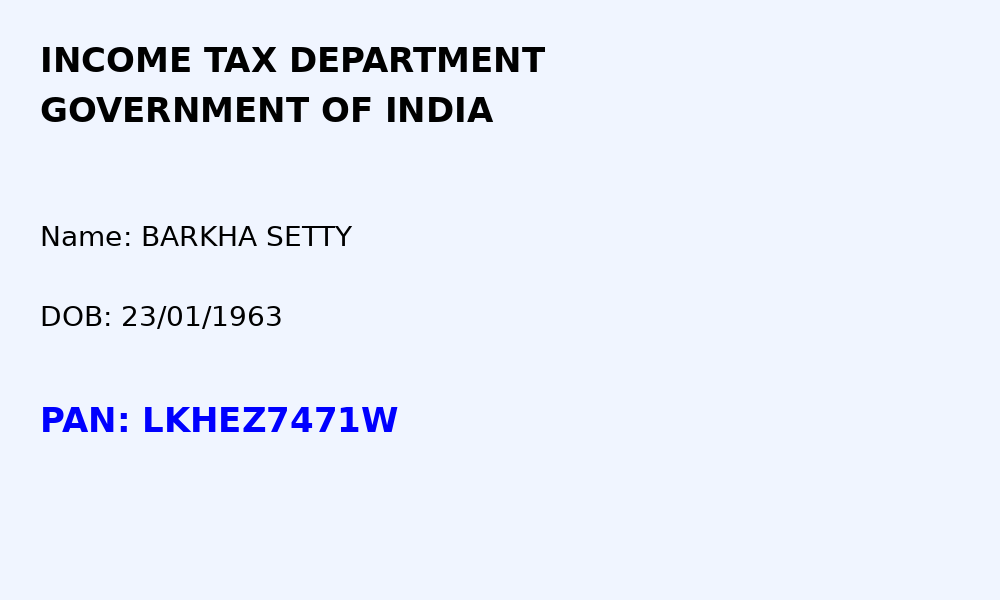

In [39]:
from PIL import Image

Image.open("pan_images/PAN_002.png")


In [42]:
#bank data creation
import pandas as pd
import random


# ==========================
# LOAD CUSTOMER KYC CSV
# ==========================

df = pd.read_csv(
    "/data/pan_ground_truth.csv"
)


# ==========================
# CREATE BANK CSV
# ==========================

bank_df = df.copy()


# Add bank customer id

bank_df.insert(
    0,
    "customer_id",
    range(
        100001,
        100001 + len(bank_df)
    )
)


# Shuffle income slightly
bank_df["income"] = [

    random.randint(
        300000,
        3000000
    )

    for _ in range(
        len(bank_df)
    )

]


# Keep only bank fields

bank_df = bank_df[

    [

        "customer_id",

        "name",

        "dob",

        "pan",

        "income"

    ]

]


# ==========================
# SAVE
# ==========================

bank_df.to_csv(

    "data/bank_customer_master.csv",

    index=False

)


print(
    "bank_customer_master.csv created"
)

bank_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/data/pan_ground_truth.csv'

In [43]:
customer_id,name,dob,pan,income
100001,ARUNIMA KARI,09/02/2004,FLIMA6161F,1200000
100002,BARKHA SETTY,23/01/1963,LKHEZ7471W,850000
100003,NAKUL DOSHI,10/08/1985,HEUZT3916E,1800000
100004,BAGHYAWATI DANI,31/08/1975,CQMUT8940X,950000
100005,HARINAKSHI MUNSHI,10/05/1968,ACHIB9618A,2200000
100006,GIRINDRA RATTAN,07/11/1961,ZBXWK7032B,780000
100007,AMRUTA MUKHOPADHYAY,23/09/1971,OKNIN9222Y,1500000
100008,YATAN ANDRA,12/05/2002,NZOQC3018Q,650000
100009,BALENDRA VISWANATHAN,08/09/1994,OQASP7854O,1400000
100010,VARSHA GILL,06/08/1977,BJQKZ6817U,900000
100011,POOJA TANK,27/10/1975,LTSYL5004T,1100000
100012,TANVI HEGDE,24/01/1986,MVPZT7260T,1700000
100013,CHRISTOPHER BARIA,15/12/1987,TKQVC2611J,1300000
100014,TARA DIN,23/01/1980,FWUUD7360L,890000
100015,PUSHTI KUMER,10/05/1964,BZKBK8915V,760000
100016,TURVI AURORA,11/12/1985,ATLCI9949Q,1950000
100017,ABDUL DUGAL,15/08/1976,TRITB9143Z,1020000
100018,SHAURYA RASTOGI,16/10/1991,UXIGH6235U,2500000
100019,JASON CHAUHAN,24/04/1966,CACAT2109O,810000
100020,ISAAC SANDAL,23/09/1979,HKQME9829E,980000
100021,OLIVER KARI,02/10/1994,LOAXW2259M,1750000
100022,PRIYA KARA,03/09/1965,LFZQP1837A,870000
100023,BALVEER LUTHRA,01/06/1973,XQODZ4713M,1320000
100024,VASANA KARAN,21/03/2005,ZTOFL2554Y,620000
100025,CHRISTOPHER MALL,24/04/1974,DSWCD2647S,1850000
100026,OSHA JOHAL,02/07/1967,VVVUR1035E,920000
100027,CHAMPAK KEER,15/10/1999,WPTDB1244O,710000
100028,UCCHAL GOEL,15/08/1984,AUUCJ8597J,1600000
100029,SAANVI CHEEMA,21/08/2001,KKLKB2907K,990000
100030,ANITA RAO,29/06/1974,ZTJXT3858L,1460000
100031,GAGAN DUGAR,27/06/1968,XHQEL8189L,840000
100032,MASON BHATTACHARYYA,06/05/1982,TAWKQ8212C,1550000
100033,NITARA GUHA,03/12/2000,WWABK2912S,680000
100034,EIRAVATI KARNIK,09/06/2002,YPZHM6103U,720000
100035,KALA TANK,10/03/1975,DBQKS7295B,1050000
100036,YASHAWINI RAM,03/09/2004,WKVGW6782P,590000
100037,HEMA DASH,07/08/1981,DFBSO8289X,1420000
100038,DAMYANTI KAUL,12/06/1985,XPHYK7395W,2100000
100039,ODIKA RAO,17/08/2007,DZFJW8802M,480000
100040,MADHAV MAMMEN,16/01/1997,BHMQM8711X,1690000
100041,QUINCY KURIAN,28/05/2004,IHZWA1317O,610000
100042,SUHANI GROVER,19/02/1985,REPOG2805R,1360000
100043,YUVRAJ SWAMY,18/05/2000,MIARQ5478H,970000
100044,VANSHA WALIA,01/01/1980,VBQXP2929Q,1230000
100045,HRITIK BANDI,24/02/1971,PKUGD7102B,940000
100046,VIRAJ SARKAR,17/04/1997,YFVDO1751G,1710000
100047,VRISHTI GARA,23/12/1970,XKKXS5274G,1150000
100048,ISHAAN CHEEMA,28/06/1965,MTQQR9166A,880000
100049,ABEER KALITA,31/08/1970,AJZCE9462U,1620000
100050,UCCHAL GOYAL,03/07/1995,VRVRL3246T,1920000

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (3681108462.py, line 2)

In [47]:
import pandas as pd
import random
import os
from datetime import datetime
from datetime import timedelta


# ==========================
# CREATE FOLDER
# ==========================

os.makedirs(
    "data",
    exist_ok=True
)


# ==========================
# RANDOM VALUES
# ==========================

modes = [

    "cash",
    "upi",
    "salary",
    "card",
    "imps",
    "neft",
    "atm"

]


transaction_types = [

    "credit",
    "debit"

]


categories = [

    "salary",
    "shopping",
    "food",
    "travel",
    "rent",
    "bill_payment",
    "investment",
    "transfer"

]


cities = [

    "Mumbai",
    "Pune",
    "Delhi",
    "Bangalore",
    "Hyderabad",
    "Chennai"

]


# ==========================
# DATE GENERATOR
# ==========================

def generate_date():

    start = datetime(
        2025,
        1,
        1
    )

    end = datetime(
        2026,
        6,
        1
    )

    delta = (
        end
        -
        start
    )

    days = random.randint(
        0,
        delta.days
    )

    return (

        start
        +

        timedelta(
            days=days
        )

    ).strftime(
        "%Y-%m-%d"
    )


# ==========================
# REALISTIC AMOUNT
# ==========================

def generate_amount():

    chance = random.random()

    if chance < 0.70:

        return round(

            random.uniform(
                100,
                5000
            ),

            2

        )

    elif chance < 0.95:

        return round(

            random.uniform(
                5000,
                50000
            ),

            2

        )

    else:

        return round(

            random.uniform(
                50000,
                150000
            ),

            2

        )


# ==========================
# GENERATE 1000 TXNS
# ==========================

records = []


for i in range(1,1001):

    customer_id = random.randint(

        100001,
        100100

    )

    records.append({

        "transaction_id":
        i,

        "customer_id":
        customer_id,

        "transaction_date":
        generate_date(),

        "transaction_type":
        random.choice(
            transaction_types
        ),

        "amount":
        generate_amount(),

        "mode":
        random.choice(
            modes
        ),

        "merchant_category":
        random.choice(
            categories
        ),

        "city":
        random.choice(
            cities
        ),

        "is_international":
        random.choice(
            [0,0,0,1]
        ),

        "account_balance":
        round(

            random.uniform(
                5000,
                500000
            ),

            2

        )

    })


# ==========================
# SAVE CSV
# ==========================

transactions_df = pd.DataFrame(
    records
)

transactions_df.to_csv(

    "data/transactions.csv",

    index=False

)


print(
    "1000 transactions created"
)

print(
    "transactions.csv created"
)

transactions_df.head()

1000 transactions created
transactions.csv created


,transaction_id,customer_id,transaction_date,transaction_type,amount,mode,merchant_category,city,is_international,account_balance
0,1,100063,2025-11-21,debit,4067.43,cash,rent,Delhi,0,481662.15
1,2,100056,2025-04-27,debit,23902.56,card,salary,Bangalore,0,301080.81
2,3,100031,2025-04-12,debit,8758.94,imps,salary,Bangalore,0,84557.67
3,4,100009,2025-01-29,debit,18548.23,atm,food,Pune,1,498628.69
4,5,100041,2026-04-22,credit,3453.15,upi,travel,Chennai,1,194176.68
